# Imports et Connexion

In [ ]:

from google.colab import drive
from pathlib import Path
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Tuple

drive.mount('/content/drive')

RAW_DATA_PATH = Path('/content/drive/MyDrive/Crop_Classification/data/raw')
PROCESSED_DATA_PATH = Path('/content/drive/MyDrive/Crop_Classification/data/processed')

for state in ['arkansas', 'california']:
    (PROCESSED_DATA_PATH / state).mkdir(parents=True, exist_ok=True)

print(f"Dossier raw: {RAW_DATA_PATH.exists()}")
print(f" Dossier processed: {PROCESSED_DATA_PATH.exists()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dossier raw: True
✅ Dossier processed: True


# Configuration Temporelle

In [ ]:

YEAR = 2021
N_INTERVALS = 36
INTERVAL_DAYS = 10
S2_BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]
FEATURE_COLUMNS = [f"{band}_t{t:02d}" for t in range(1, N_INTERVALS + 1) for band in S2_BANDS]

CLASS_CONFIG = {
    "Arkansas": {
        "classes": {
            5: {"name": "Soybeans", "total": 4677, "train": 240, "val": 60, "test": 4377},
            3: {"name": "Rice", "total": 2423, "train": 240, "val": 60, "test": 2123},
            2: {"name": "Cotton", "total": 762, "train": 240, "val": 60, "test": 462},
            1: {"name": "Corn", "total": 1522, "train": 240, "val": 60, "test": 1222},
        },
        "others_code": 99,
        "others_total": 616,
        "others_train": 240,
        "others_val": 60,
        "others_test": 316
    },
    "California": {
        "classes": {
            1: {"name": "Grapes", "total": 2054, "train": 240, "val": 60, "test": 1754},
            2: {"name": "Rice", "total": 2037, "train": 240, "val": 60, "test": 1737},
            3: {"name": "Alfalfa", "total": 974, "train": 240, "val": 60, "test": 674},
            4: {"name": "Almonds", "total": 783, "train": 240, "val": 60, "test": 483},
            5: {"name": "Pistachios", "total": 640, "train": 240, "val": 60, "test": 340},
        },
        "others_code": 99,
        "others_total": 3512,
        "others_train": 240,
        "others_val": 60,
        "others_test": 3212
    }
}

# Définition des Fonctions de Traitement

In [ ]:
def load_and_preprocess_csv(csv_path: Path, state_name: str) -> pd.DataFrame:
    print(f"   Chargement: {csv_path.name}")
    df = pd.read_csv(csv_path)

    print(f"   Labels avant traitement: {sorted(df['label'].unique())}")

    feature_cols = [col for col in df.columns if '_t' in col]
    df[feature_cols] = df[feature_cols].fillna(0)
    print(f"   1. NaN → 0: {len(feature_cols)} colonnes traitées")

    if 'confidence' in df.columns:
        before = len(df)
        df = df[df['confidence'] >= 95]
        print(f"   2. Filtrage confiance ≥95%: {before} → {len(df)}")
    else:
        print(f"   2.  Pas de colonne 'confidence' - filtrage ignoré")

    if 'worldcover' in df.columns:
        before = len(df)
        df = df[df['worldcover'] == 40]
        print(f"   3. Masquage non-cropland: {before} → {len(df)}")
    else:
        print(f"   3.  Pas de colonne 'worldcover' - masquage ignoré")

    before = len(df)
    df = df.dropna(subset=['label'])
    df['label'] = df['label'].astype(int)
    print(f"   4. Labels valides: {before} → {len(df)}")

    print(f"   Labels après traitement: {sorted(df['label'].unique())}")

    expected_codes = list(CLASS_CONFIG[state_name]['classes'].keys())
    missing_codes = [c for c in expected_codes if c not in df['label'].unique()]
    if missing_codes:
        print(f"    CODES MANQUANTS APRÈS TRAITEMENT: {missing_codes}")
    else:
        print(f"    Tous les codes attendus sont présents")

    return df


def split_according_to_table2(df: pd.DataFrame, state_name: str) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    config = CLASS_CONFIG[state_name]
    train_list, val_list, test_list = [], [], []

    others_code = config.get('others_code', 99)

    print(f"\n    Distribution par classe :")
    print(f"   {'Classe':<15} {'Dispo':<8} {'Attendu':<8} {'Train':<8} {'Val':<8} {'Test':<8}")
    print(f"   {'-'*60}")

    for code, info in config['classes'].items():
        class_df = df[df['label'] == code]
        disponible = len(class_df)

        print(f"   {info['name']:<15} {disponible:<8} {info['total']:<8} ", end="")

        if disponible == 0:
            print(f"❌ CLASSE VIDE !")
            continue

        if disponible >= info['total']:
            sampled = class_df.sample(n=info['total'], random_state=42)
        else:
            sampled = class_df
            print(f"\n       Seulement {disponible}/{info['total']} disponible", end="")

        train_part = sampled.head(info['train'])
        val_part = sampled.iloc[info['train']:info['train']+info['val']]
        test_part = sampled.tail(info['test'])

        print(f"{len(train_part):<8} {len(val_part):<8} {len(test_part):<8}")

        train_list.append(train_part)
        val_list.append(val_part)
        test_list.append(test_part)

    main_codes = list(config['classes'].keys())
    others_df = df[df['label'] == others_code]
    disponible = len(others_df)

    print(f"   {'Others':<15} {disponible:<8} {config['others_total']:<8} ", end="")

    if disponible >= config['others_total']:
        others_sampled = others_df.sample(n=config['others_total'], random_state=42)
    else:
        others_sampled = others_df
        print(f"\n       Seulement {disponible}/{config['others_total']} disponible", end="")

    train_others = others_sampled.head(config['others_train'])
    val_others = others_sampled.iloc[config['others_train']:config['others_train']+config['others_val']]
    test_others = others_sampled.tail(config['others_test'])

    print(f"{len(train_others):<8} {len(val_others):<8} {len(test_others):<8}")

    train_list.append(train_others)
    val_list.append(val_others)
    test_list.append(test_others)

    train_df = pd.concat(train_list, ignore_index=True)
    val_df = pd.concat(val_list, ignore_index=True)
    test_df = pd.concat(test_list, ignore_index=True)

    print(f"\n    TOTAL: Train={len(train_df)} | Val={len(val_df)} | Test={len(test_df)}")

    return train_df, val_df, test_df


def save_as_npz(state_name: str, train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame):
    state_dir = PROCESSED_DATA_PATH / state_name.lower()
    state_dir.mkdir(parents=True, exist_ok=True)

    all_labels = pd.concat([train_df['label'], val_df['label'], test_df['label']]).unique()
    all_labels = sorted(all_labels)

    class_to_idx = {int(c): i for i, c in enumerate(all_labels)}
    idx_to_class = {i: int(c) for i, c in enumerate(all_labels)}

    print(f"\n   📋 Mapping des classes :")
    for code, idx in class_to_idx.items():
        config = CLASS_CONFIG[state_name]
        if code in config['classes']:
            name = config['classes'][code]['name']
        else:
            name = "Others"
        print(f"      Code {code} ({name}) → Indice {idx}")

    for split_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        if len(df) > 0:
            X = df[FEATURE_COLUMNS].to_numpy(dtype=np.float32)
            X = X.reshape(-1, N_INTERVALS, len(S2_BANDS))

            y = df['label'].map(class_to_idx).to_numpy(dtype=np.int64)

            if np.isnan(y).any():
                print(f"    ERREUR: NaN dans y pour {split_name}")
                continue

            save_path = state_dir / f"{split_name}.npz"
            np.savez_compressed(save_path, X=X, y=y)

            unique_idx, counts = np.unique(y, return_counts=True)
            print(f"\n    {split_name}.npz: {len(df)} samples")
            for idx, count in zip(unique_idx, counts):
                code = idx_to_class[idx]
                if code in CLASS_CONFIG[state_name]['classes']:
                    name = CLASS_CONFIG[state_name]['classes'][code]['name']
                else:
                    name = "Others"
                print(f"         {name}: {count} échantillons")

    metadata = {
        'state': state_name,
        'year': YEAR,
        'n_intervals': N_INTERVALS,
        'interval_days': INTERVAL_DAYS,
        'bands': S2_BANDS,
        'class_to_idx': {str(k): v for k, v in class_to_idx.items()},
        'idx_to_class': {str(k): v for k, v in idx_to_class.items()},
        'n_samples': {
            'train': len(train_df),
            'val': len(val_df),
            'test': len(test_df)
        }
    }

    with open(state_dir / 'metadata.json', 'w') as f:
        json.dump(metadata, f, indent=2)
    print(f"\n    metadata.json sauvegardé")


def compute_and_plot_ndvi(state_name: str, train_df: pd.DataFrame):
    state_dir = PROCESSED_DATA_PATH / state_name.lower()

    config = CLASS_CONFIG[state_name]
    class_names = {code: info['name'] for code, info in config['classes'].items()}

    plt.figure(figsize=(14, 8))

    for code, name in class_names.items():
        class_df = train_df[train_df['label'] == code]
        if len(class_df) == 0:
            continue

        ndvi_vals = []
        for t in range(1, N_INTERVALS + 1):
            b8_col = f"B8_t{t:02d}"
            b4_col = f"B4_t{t:02d}"

            if b8_col in class_df.columns and b4_col in class_df.columns:
                b8 = class_df[b8_col].values
                b4 = class_df[b4_col].values
                denominator = b8 + b4
                ndvi = np.where(denominator != 0, (b8 - b4) / denominator, 0)
                ndvi_vals.append(np.nanmean(ndvi))
            else:
                ndvi_vals.append(0)

        days = np.arange(1, N_INTERVALS + 1) * 10
        plt.plot(days, ndvi_vals, label=name, linewidth=2)

    plt.xlabel('Jour de l\'année', fontsize=12)
    plt.ylabel('NDVI', fontsize=12)
    plt.title(f'Courbes NDVI moyennes - {state_name} (2021)', fontsize=14)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.2, 1.0)

    save_path = state_dir / 'ndvi_curves.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"    NDVI curves sauvegardées: {save_path}")
    plt.show()

In [ ]:


print("\n" + "="*60)
print("🔍 DIAGNOSTIC DES LABELS DANS LES CSV")
print("="*60)

def diagnose_csv(state_name):
    csv_path = RAW_DATA_PATH / f"mctnet_preprocessed_{state_name.lower()}_2021.csv"

    if not csv_path.exists():
        print(f" Fichier non trouvé : {csv_path}")
        return None

    print(f"\n {state_name.upper()}")
    print("-" * 40)

    df = pd.read_csv(csv_path)

    print(f"\n1. Labels uniques dans le CSV :")
    unique_labels = sorted(df['label'].unique())
    print(f"   {unique_labels}")

    print(f"\n2. Distribution complète :")
    for label, count in df['label'].value_counts().sort_index().items():
        pct = count / len(df) * 100
        print(f"   Label {label:>3} : {count:>6} échantillons ({pct:.1f}%)")

    print(f"\n3. Colonnes spéciales présentes :")
    for col in ['confidence', 'worldcover']:
        if col in df.columns:
            print(f"   '{col}' est présente")
        else:
            print(f"    '{col}' est ABSENTE")

    return df

df_ar_raw = diagnose_csv("Arkansas")
df_ca_raw = diagnose_csv("California")


🔍 DIAGNOSTIC DES LABELS DANS LES CSV

📁 ARKANSAS
----------------------------------------

1. Labels uniques dans le CSV :
   [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(99)]

2. Distribution complète :
   Label   1 :   1522 échantillons (15.2%)
   Label   2 :    762 échantillons (7.6%)
   Label   3 :   2423 échantillons (24.2%)
   Label   5 :   4677 échantillons (46.8%)
   Label  99 :    616 échantillons (6.2%)

3. Colonnes spéciales présentes :
   ❌ 'confidence' est ABSENTE
   ❌ 'worldcover' est ABSENTE

📁 CALIFORNIA
----------------------------------------

1. Labels uniques dans le CSV :
   [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(99)]

2. Distribution complète :
   Label   1 :   2054 échantillons (20.5%)
   Label   2 :   2037 échantillons (20.4%)
   Label   3 :    974 échantillons (9.7%)
   Label   4 :    783 échantillons (7.8%)
   Label   5 :    640 échantillons (6.4%)
   Label  99 :   3512 échantillons (35.1%)

3. Colonnes spé

/tmp/ipykernel_8768/657439893.py:19: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


 Exécution pour ARKANSAS


🔧 TRAITEMENT DE L'ARKANSAS
   Chargement: mctnet_preprocessed_arkansas_2021.csv
   Labels avant traitement: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(99)]
   1. NaN → 0: 360 colonnes traitées
   2. ⚠️ Pas de colonne 'confidence' - filtrage ignoré
   3. ⚠️ Pas de colonne 'worldcover' - masquage ignoré
   4. Labels valides: 10000 → 10000
   Labels après traitement: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(99)]
   ✅ Tous les codes attendus sont présents

   📊 Distribution par classe :
   Classe          Dispo    Attendu  Train    Val      Test    
   ------------------------------------------------------------
   Soybeans        4677     4677     240      60       4377    
   Rice            2423     2423     240      60       2123    
   Cotton          762      762      240      60       462     
   Corn            1522     1522     240      60       1222    
   Others          616      616      240      60       316     

   ✅ TOTAL: Train=1200

/tmp/ipykernel_8768/1035476179.py:217: RuntimeWarning: invalid value encountered in divide
  ndvi = np.where(denominator != 0, (b8 - b4) / denominator, 0)


   📊 NDVI curves sauvegardées: /content/drive/MyDrive/Crop_Classification/data/processed/arkansas/ndvi_curves.png


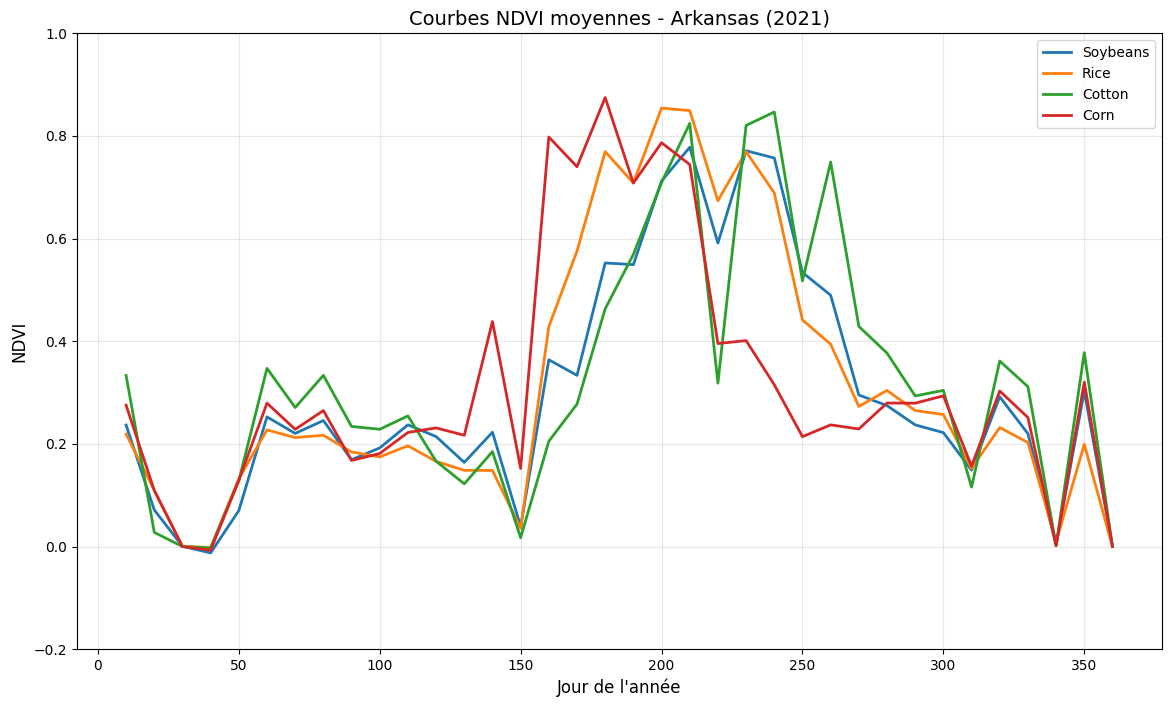

In [ ]:

print("\n" + "="*60)
print("🔧 TRAITEMENT DE L'ARKANSAS")
print("="*60)

ar_csv = RAW_DATA_PATH / "mctnet_preprocessed_arkansas_2021.csv"

if ar_csv.exists():
    df_ar = load_and_preprocess_csv(ar_csv, "Arkansas")

    if len(df_ar) == 0:
        print(" ERREUR: DataFrame vide après preprocessing !")
    else:
        train_ar, val_ar, test_ar = split_according_to_table2(df_ar, "Arkansas")

        save_as_npz("Arkansas", train_ar, val_ar, test_ar)

        compute_and_plot_ndvi("Arkansas", train_ar)
else:
    print(f" Fichier non trouvé: {ar_csv}")
    print("   Vérifiez que le fichier a bien été exporté depuis GEE")

In [ ]:
from pathlib import Path

RAW_DATA_PATH = Path('/content/drive/MyDrive/Crop_Classification/data/raw')

print("Contenu du dossier raw :")
print("="*50)

for item in RAW_DATA_PATH.iterdir():
    if item.is_file():
        size_mb = item.stat().st_size / (1024*1024)
        print(f"📄 {item.name} ({size_mb:.1f} MB)")
    elif item.is_dir():
        print(f" {item.name}/")

print("\n" + "="*50)
print("Recherche de '*california*' :")
for item in RAW_DATA_PATH.glob("*[Cc]alifornia*"):
    print(f"  → {item}")

Contenu du dossier raw :
📄 mctnet_preprocessed_california_2021.csv (23.2 MB)
📄 mctnet_preprocessed_arkansas_2021.csv (22.4 MB)

Recherche de '*california*' :
  → /content/drive/MyDrive/Crop_Classification/data/raw/mctnet_preprocessed_california_2021.csv


Exécution pour CALIFORNIA


🔧 TRAITEMENT DE LA CALIFORNIE
   ✅ Fichier trouvé : mctnet_preprocessed_california_2021.csv
   Chargement: mctnet_preprocessed_california_2021.csv


/tmp/ipykernel_8768/1035476179.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


   Labels avant traitement: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(99)]
   1. NaN → 0: 360 colonnes traitées
   2. ⚠️ Pas de colonne 'confidence' - filtrage ignoré
   3. ⚠️ Pas de colonne 'worldcover' - masquage ignoré
   4. Labels valides: 10000 → 10000
   Labels après traitement: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(99)]
   ✅ Tous les codes attendus sont présents

   📊 Distribution par classe :
   Classe          Dispo    Attendu  Train    Val      Test    
   ------------------------------------------------------------
   Grapes          2054     2054     240      60       1754    
   Rice            2037     2037     240      60       1737    
   Alfalfa         974      974      240      60       674     
   Almonds         783      783      240      60       483     
   Pistachios      640      640      240      60       340     
   Others          3512     3512     240      60       3212    

   ✅ TOTAL: T

/tmp/ipykernel_8768/1035476179.py:217: RuntimeWarning: invalid value encountered in divide
  ndvi = np.where(denominator != 0, (b8 - b4) / denominator, 0)


   📊 NDVI curves sauvegardées: /content/drive/MyDrive/Crop_Classification/data/processed/california/ndvi_curves.png


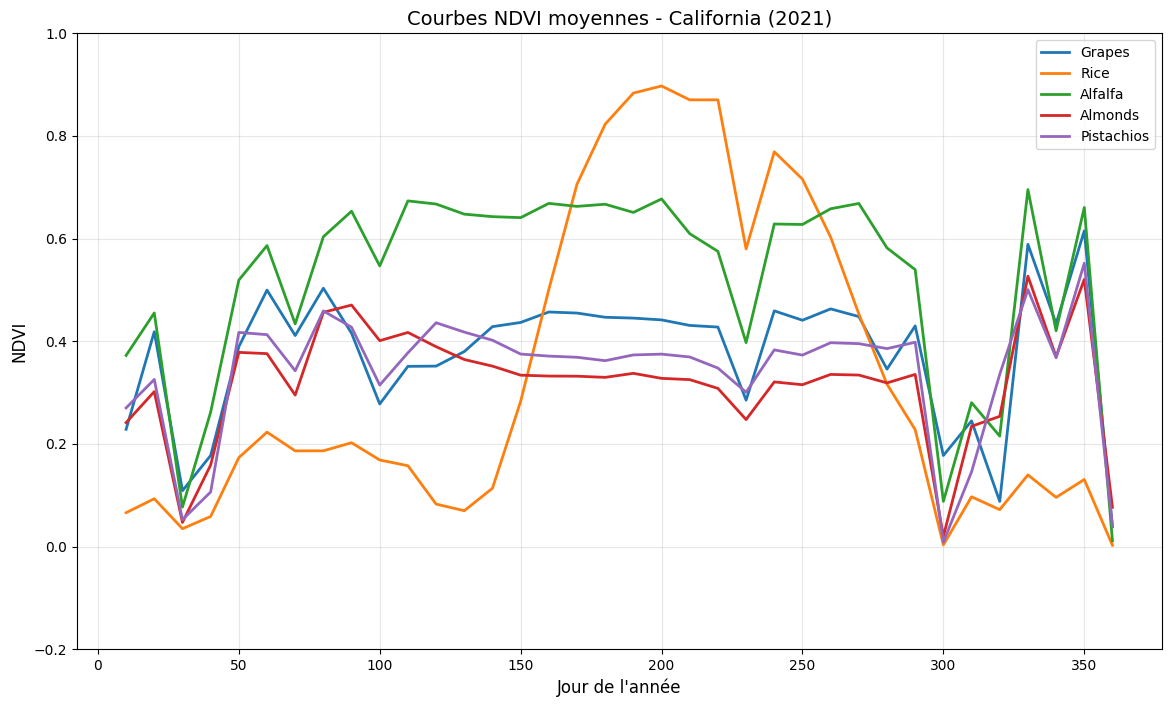

In [ ]:

print("\n" + "="*60)
print("🔧 TRAITEMENT DE LA CALIFORNIE")
print("="*60)

ca_csv = RAW_DATA_PATH / "mctnet_preprocessed_california_2021.csv"

if ca_csv.exists():
    print(f"    Fichier trouvé : {ca_csv.name}")

    df_ca = load_and_preprocess_csv(ca_csv, "California")

    if len(df_ca) == 0:
        print(" ERREUR: DataFrame vide après preprocessing !")
    else:
        train_ca, val_ca, test_ca = split_according_to_table2(df_ca, "California")

        save_as_npz("California", train_ca, val_ca, test_ca)

        compute_and_plot_ndvi("California", train_ca)
else:
    print(f" Fichier non trouvé: {ca_csv}")

Vérification finale

In [ ]:

print("\n" + "="*60)
print("PREPROCESSING TERMINÉ !")
print("="*60)

print("\n Structure générée:")
print("   /content/drive/MyDrive/Crop_Classification/data/processed/")
print("   ├── arkansas/")
print("   │   ├── train.npz")
print("   │   ├── val.npz")
print("   │   ├── test.npz")
print("   │   ├── metadata.json")
print("   │   └── ndvi_curves.png")
print("   └── california/")
print("       ├── train.npz")
print("       ├── val.npz")
print("       ├── test.npz")
print("       ├── metadata.json")
print("       └── ndvi_curves.png")

for state in ['arkansas', 'california']:
    state_dir = PROCESSED_DATA_PATH / state
    if state_dir.exists():
        files = list(state_dir.glob('*'))
        print(f"\n {state}: {len(files)} fichiers")
        for f in files:
            size = f.stat().st_size / 1024
            print(f"   - {f.name} ({size:.1f} KB)")


✅ PREPROCESSING TERMINÉ !

📂 Structure générée:
   /content/drive/MyDrive/Crop_Classification/data/processed/
   ├── arkansas/
   │   ├── train.npz
   │   ├── val.npz
   │   ├── test.npz
   │   ├── metadata.json
   │   └── ndvi_curves.png
   └── california/
       ├── train.npz
       ├── val.npz
       ├── test.npz
       ├── metadata.json
       └── ndvi_curves.png

📁 arkansas: 5 fichiers
   - ndvi_curves.png (200.8 KB)
   - train.npz (857.8 KB)
   - metadata.json (0.4 KB)
   - val.npz (216.7 KB)
   - test.npz (6104.0 KB)

📁 california: 5 fichiers
   - train.npz (1095.2 KB)
   - val.npz (276.2 KB)
   - test.npz (6094.3 KB)
   - metadata.json (0.5 KB)
   - ndvi_curves.png (223.0 KB)
